# 🔍 Obstacle Detection - Dedicated Testing Suite
### Interactive PyCharm Notebook for Evaluating the Trained Model

This testing notebook loads your saved model (`weights/obstacle_yolo_best.pt` or `.onnx`), evaluates sample images, and features **Assistive Navigation Corridor Analysis** (Left, Center, and Right zones) with simulated proximity warnings for visually impaired navigation.

## 1. Setup & Imports

In [1]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import time

print("Testing dependencies imported.")


Testing dependencies imported.


## 2. Load Trained Model & Metadata
Loads the saved model weights (`weights/obstacle_yolo_best.pt` or fallback).

In [2]:
weights_path = Path("weights/obstacle_yolo_best.pt")
if not weights_path.exists():
    print(f"[!] {weights_path} not found yet. Using 'yolov8n.pt' for demonstration.")
    weights_path = Path("yolov8n.pt")

model = YOLO(str(weights_path))
print(f"Loaded model: {weights_path}")

# Load metadata if available
meta_path = Path("weights/classes.json")
if meta_path.exists():
    with open(meta_path, "r") as f:
        metadata = json.load(f)
    CLASSES = metadata.get("classes", [])
    print(f"Loaded {len(CLASSES)} target classes: {CLASSES}")
else:
    CLASSES = list(model.names.values())
    print(f"Using model class names: {CLASSES[:10]}...")


Loaded model: weights\obstacle_yolo_best.pt
Loaded 9 target classes: ['car', 'bike', 'bus', 'chair', 'table', 'pole', 'person', 'stairs', 'wall']


## 3. Assistive Navigation Corridor Logic
Partitions the camera field of view into **Left**, **Center**, and **Right** corridors. Estimates obstacle proximity based on bounding box height relative to the image frame.

In [3]:
def analyze_assistive_navigation(img_w, img_h, boxes, names):
    """
    Analyzes detected bounding boxes to generate spatial audio warnings for blind navigation.
    """
    left_boundary = img_w * 0.33
    right_boundary = img_w * 0.66
    
    alerts = []
    
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = float(box.conf[0])
        cls_id = int(box.cls[0])
        label = names.get(cls_id, f"Object_{cls_id}")
        
        # Calculate center x and box height
        cx = (x1 + x2) / 2.0
        box_h = y2 - y1
        height_ratio = box_h / img_h
        
        # Determine Zone
        if cx < left_boundary:
            zone = "Left"
        elif cx > right_boundary:
            zone = "Right"
        else:
            zone = "Center (Direct Path!)"
            
        # Estimate Proximity
        if height_ratio > 0.45:
            proximity = "CRITICAL: Very Close (< 1.5m)"
        elif height_ratio > 0.25:
            proximity = "WARNING: Approaching (2-3m)"
        else:
            proximity = "INFO: Distant (> 3m)"
            
        alerts.append({
            "label": label,
            "conf": conf,
            "zone": zone,
            "proximity": proximity,
            "bbox": (int(x1), int(y1), int(x2), int(y2))
        })
        
    return alerts

print("Assistive navigation logic defined.")


Assistive navigation logic defined.


## 4. Single Image Testing with Visual Corridor Overlays


0: 480x640 1 orange, 9.3ms
Speed: 117.7ms preprocess, 9.3ms inference, 15.4ms postprocess per image at shape (1, 3, 480, 640)


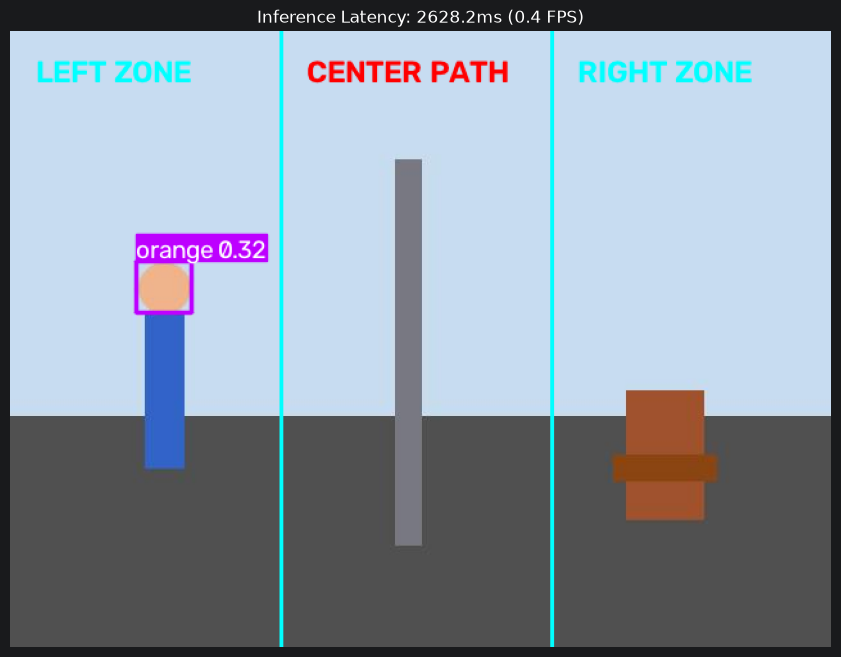


🔊 ASSISTIVE AUDIO WARNINGS GENERATED:
  ▶ [INFO: Distant (> 3m)] ORANGE detected in Left (Confidence: 32.4%)


In [4]:
test_image_file = "data/test_samples/synthetic_street_sample.jpg"

if os.path.exists(test_image_file):
    # Read image
    img = cv2.imread(test_image_file)
    h, w = img.shape[:2]
    
    # Run inference
    start_t = time.perf_counter()
    results = model(img, conf=0.25)[0]
    latency_ms = (time.perf_counter() - start_t) * 1000
    
    # Plot detections with navigation corridors
    annotated = results.plot()
    
    # Draw corridor lines
    cv2.line(annotated, (int(w * 0.33), 0), (int(w * 0.33), h), (255, 255, 0), 2)
    cv2.line(annotated, (int(w * 0.66), 0), (int(w * 0.66), h), (255, 255, 0), 2)
    cv2.putText(annotated, "LEFT ZONE", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)
    cv2.putText(annotated, "CENTER PATH", (int(w * 0.33) + 20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    cv2.putText(annotated, "RIGHT ZONE", (int(w * 0.66) + 20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)
    
    # Display image
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"Inference Latency: {latency_ms:.1f}ms ({1000/latency_ms:.1f} FPS)")
    plt.axis("off")
    plt.show()
    
    # Navigation Audio Simulation
    alerts = analyze_assistive_navigation(w, h, results.boxes, results.names)
    print("\n🔊 ASSISTIVE AUDIO WARNINGS GENERATED:")
    if alerts:
        for a in alerts:
            print(f"  ▶ [{a['proximity']}] {a['label'].upper()} detected in {a['zone']} (Confidence: {a['conf']*100:.1f}%)")
    else:
        print("  ▶ Path is clear. No obstacles detected.")
else:
    print(f"Test image not found at {test_image_file}")


## 5. Batch Image Testing
Test all images inside `data/test_samples/` folder.

In [5]:
sample_dir = Path("data/test_samples")
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
image_files = [p for p in sample_dir.glob("*") if p.suffix.lower() in image_extensions]

print(f"Found {len(image_files)} test images in {sample_dir}.")

for img_path in image_files:
    res = model(str(img_path), conf=0.3)[0]
    num_dets = len(res.boxes)
    detected_names = [res.names[int(b.cls[0])] for b in res.boxes]
    print(f"- {img_path.name}: {num_dets} obstacles detected -> {detected_names}")


Found 1 test images in data\test_samples.

image 1/1 F:\embedded_project\data\test_samples\synthetic_street_sample.jpg: 480x640 1 orange, 117.8ms
Speed: 4.1ms preprocess, 117.8ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
- synthetic_street_sample.jpg: 1 obstacles detected -> ['orange']


## 6. Real-Time Latency Benchmark
Measures average inference time and FPS over 50 consecutive runs to ensure embedded deployment readiness.

In [6]:
import numpy as np
dummy_frame = np.zeros((640, 640, 3), dtype=np.uint8)

# Warmup
for _ in range(5):
    _ = model(dummy_frame, verbose=False)

latencies = []
num_runs = 50
print(f"Benchmarking inference latency over {num_runs} runs...")

for _ in range(num_runs):
    t0 = time.perf_counter()
    _ = model(dummy_frame, verbose=False)
    latencies.append((time.perf_counter() - t0) * 1000)

avg_ms = np.mean(latencies)
fps = 1000.0 / avg_ms
print(f"\n⚡ BENCHMARK RESULTS:")
print(f"Average Latency : {avg_ms:.2f} ms")
print(f"Throughput      : {fps:.1f} FPS")
print(f"Min / Max       : {np.min(latencies):.2f} ms / {np.max(latencies):.2f} ms")


Benchmarking inference latency over 50 runs...

⚡ BENCHMARK RESULTS:
Average Latency : 14.99 ms
Throughput      : 66.7 FPS
Min / Max       : 7.74 ms / 128.71 ms


## 7. Upload & Test a Single Image
Select and upload any image from your computer to run obstacle detection and visualize the **Assistive Navigation Corridor Overlays**.

Opening file browser dialog... Please select an image from your PC.
[✓] Selected image: C:/Users/samee/Downloads/Bus_picture.jpg

0: 448x640 4 persons, 6 cars, 1 bus, 2 traffic lights, 208.4ms
Speed: 18.8ms preprocess, 208.4ms inference, 5.3ms postprocess per image at shape (1, 3, 448, 640)


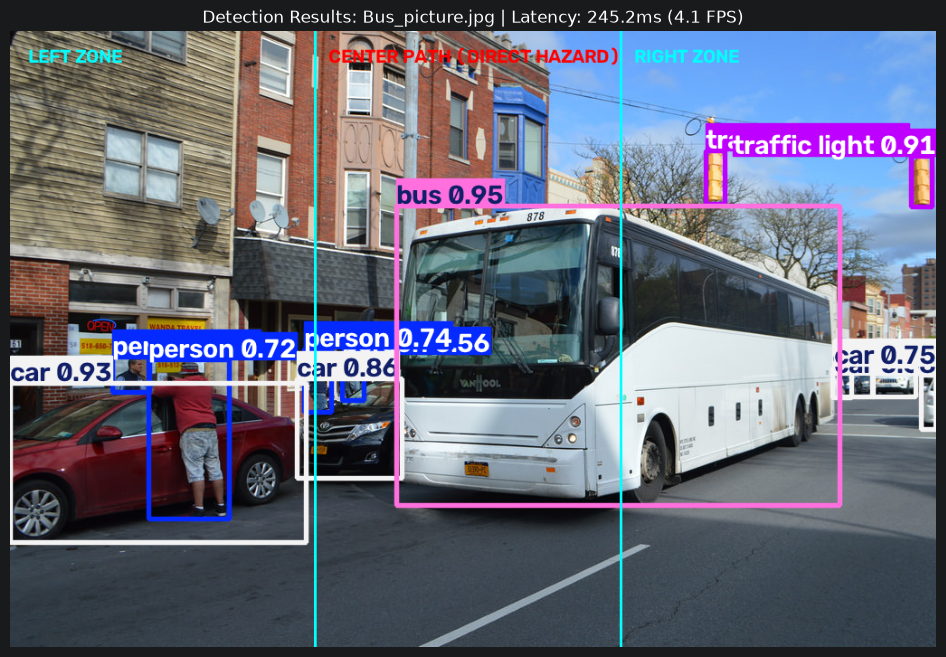


🔊 ASSISTIVE NAVIGATION REPORT: Bus_picture.jpg
  1. [CRITICAL: Very Close (< 1.5m)] BUS in Center (Direct Path!) (Confidence: 95.5%)
  2. [WARNING: Approaching (2-3m)] CAR in Left (Confidence: 93.2%)
  3. [INFO: Distant (> 3m)] TRAFFIC LIGHT in Right (Confidence: 90.6%)
  4. [INFO: Distant (> 3m)] CAR in Center (Direct Path!) (Confidence: 85.7%)
  5. [INFO: Distant (> 3m)] CAR in Right (Confidence: 74.8%)
  6. [INFO: Distant (> 3m)] PERSON in Center (Direct Path!) (Confidence: 73.5%)
  7. [WARNING: Approaching (2-3m)] PERSON in Left (Confidence: 72.4%)
  8. [INFO: Distant (> 3m)] PERSON in Left (Confidence: 70.6%)
  9. [INFO: Distant (> 3m)] CAR in Right (Confidence: 67.6%)
  10. [INFO: Distant (> 3m)] TRAFFIC LIGHT in Right (Confidence: 64.0%)
  11. [INFO: Distant (> 3m)] CAR in Right (Confidence: 58.9%)
  12. [INFO: Distant (> 3m)] PERSON in Center (Direct Path!) (Confidence: 55.9%)
  13. [INFO: Distant (> 3m)] CAR in Right (Confidence: 32.9%)



In [13]:
# ==============================================================================
# UPLOAD & TEST A SINGLE IMAGE
# ==============================================================================
# Set USE_FILE_DIALOG = True to open Windows file chooser to browse and pick an image.
# Or set USE_FILE_DIALOG = False and provide a direct path in MANUAL_IMAGE_PATH.
# ==============================================================================

USE_FILE_DIALOG = True
MANUAL_IMAGE_PATH = "data/test_samples/synthetic_street_sample.jpg"

selected_image_path = None

if USE_FILE_DIALOG:
    try:
        import tkinter as tk
        from tkinter import filedialog
        
        # Pop up file dialog on top of all windows
        root = tk.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        
        print("Opening file browser dialog... Please select an image from your PC.")
        chosen = filedialog.askopenfilename(
            title="Select Image for Obstacle Detection",
            filetypes=[
                ("All Image Files", "*.jpg *.jpeg *.png *.bmp *.webp"),
                ("JPEG Files", "*.jpg *.jpeg"),
                ("PNG Files", "*.png")
            ]
        )
        root.destroy()
        
        if chosen and os.path.exists(chosen):
            selected_image_path = chosen
            print(f"[✓] Selected image: {selected_image_path}")
        else:
            print("[!] File dialog was cancelled or closed. Using default sample image.")
    except Exception as e:
        print(f"[!] File dialog notice: {e}")

if not selected_image_path:
    selected_image_path = MANUAL_IMAGE_PATH

# --- Perform Obstacle Detection & Navigation Analysis ---
if os.path.exists(selected_image_path):
    img = cv2.imread(selected_image_path)
    h, w = img.shape[:2]
    
    # Run YOLOv8 inference
    t0 = time.perf_counter()
    results = model(img, conf=0.25)[0]
    latency_ms = (time.perf_counter() - t0) * 1000
    
    # Draw detections
    annotated = results.plot()
    
    # Draw Assistive Navigation Corridors (Left / Center / Right)
    line1_x = int(w * 0.33)
    line2_x = int(w * 0.66)
    cv2.line(annotated, (line1_x, 0), (line1_x, h), (255, 255, 0), 2)
    cv2.line(annotated, (line2_x, 0), (line2_x, h), (255, 255, 0), 2)
    
    # Zone Labels
    cv2.putText(annotated, "LEFT ZONE", (20, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    cv2.putText(annotated, "CENTER PATH (DIRECT HAZARD)", (line1_x + 15, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    cv2.putText(annotated, "RIGHT ZONE", (line2_x + 15, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    
    # Display image inline in notebook
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"Detection Results: {os.path.basename(selected_image_path)} | Latency: {latency_ms:.1f}ms ({1000/latency_ms:.1f} FPS)")
    plt.axis("off")
    plt.show()
    
    # Navigation Audio Simulation
    alerts = analyze_assistive_navigation(w, h, results.boxes, results.names)
    print(f"\n=======================================================")
    print(f"🔊 ASSISTIVE NAVIGATION REPORT: {os.path.basename(selected_image_path)}")
    print(f"=======================================================")
    if alerts:
        for idx, a in enumerate(alerts, 1):
            print(f"  {idx}. [{a['proximity']}] {a['label'].upper()} in {a['zone']} (Confidence: {a['conf']*100:.1f}%)")
    else:
        print("  [✓] Direct path is clear! No immediate obstacles detected.")
    print(f"=======================================================\n")
else:
    print(f"[!] Image file not found: {selected_image_path}")
